# Lab 1 — Streaming Classification Pipeline (AG News)

This lab shows a production-style streaming input pipeline for text **classification** using the AG News dataset.

What you’ll see:
- Windowed (approximate) stream shuffling to recover randomness while streaming
- Dynamic padding inside the collator (less padding waste)
- Multiprocessing-ready design (sharding + resume cursors)
- Lightweight throughput and dataset sanity visualizations
- Quick decode “inspect” snippets for correctness

> Default model: **distilbert-base-uncased**
> Default dataset: **ag_news** (streaming split: `train`)


In [3]:
# Standard libs
import time, random, collections
# Third-party
import torch
from torch.utils.data import IterableDataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

# Matplotlib note: VS Code Jupyter auto-handles inline figures
# If you run this in a plain notebook, you could uncomment:
# %matplotlib inline

# Core configuration you can tweak
MODEL_NAME = "distilbert-base-uncased"
BATCH_SIZE = 16
PAD_TO_MULTIPLE_OF = 8
SHUFFLE_BUFFER = 1024   # 0 disables; >= ~1000 gives a nice randomness boost
BATCHES_TO_COLLECT = 50 # number of batches used for stats/plots
SEED = 42


In [4]:
def windowed_shuffle(iterable, buffer_size: int = 1024, seed: int = 42):
    """
    Approximate shuffling for a streaming iterator:
      - Fill a buffer of at most `buffer_size` examples,
      - Randomly pop an element from the buffer,
      - Refill from the stream as long as there are elements left.

    This gives decent randomness without loading the entire dataset into memory.
    """
    rng = random.Random(seed)
    buffer = []
    it = iter(iterable)

    # Prime the buffer
    try:
        for _ in range(buffer_size):
            buffer.append(next(it))
    except StopIteration:
        pass  # stream shorter than buffer: we’ll drain at the end

    # Repeatedly pop random elements, refill from stream if possible
    while buffer:
        idx = rng.randrange(len(buffer))
        yield buffer.pop(idx)
        try:
            buffer.append(next(it))
        except StopIteration:
            # Can't refill; keep draining until empty
            continue


In [5]:
def dynamic_collate(batch, pad_id: int, pad_to_multiple_of: int | None = None):
    """
    Pads sequences in the *batch* to the max length of that batch (dynamic),
    optionally rounding up to a multiple (useful for tensor cores).

    batch: list of dicts with keys: input_ids, attention_mask, labels
    """
    ids = [ex["input_ids"] for ex in batch]
    attn = [ex["attention_mask"] for ex in batch]
    labels = [ex["labels"] for ex in batch]

    max_len = max(t.size(0) for t in ids)
    if pad_to_multiple_of:
        max_len = ((max_len + pad_to_multiple_of - 1) // pad_to_multiple_of) * pad_to_multiple_of

    def pad_tensor(t: torch.Tensor, value: int = 0) -> torch.Tensor:
        if t.size(0) < max_len:
            pad = torch.full((max_len - t.size(0),), value, dtype=t.dtype)
            return torch.cat([t, pad])
        return t

    return {
        "input_ids": torch.stack([pad_tensor(t, pad_id) for t in ids]),
        "attention_mask": torch.stack([pad_tensor(a, 0) for a in attn]),
        "labels": torch.stack(labels),
    }


In [6]:
class StreamingAGNews(IterableDataset):
    """
    Wraps a streaming AG News iterator with tokenization.
    Keeps it tiny on purpose: shuffling and collation happen elsewhere.
    """
    def __init__(self, stream_iter, tokenizer: AutoTokenizer):
        self.stream_iter = stream_iter
        self.tokenizer = tokenizer

    def __iter__(self):
        for ex in self.stream_iter:
            # ex has keys: "text", "label"
            toks = self.tokenizer(ex["text"], truncation=True, return_tensors="pt")
            yield {
                "input_ids": toks["input_ids"].squeeze(0),
                "attention_mask": toks["attention_mask"].squeeze(0),
                "labels": torch.tensor(ex["label"], dtype=torch.long),
            }


In [7]:
# Build tokenizer (ensure we have a pad token)
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tok.pad_token_id is None:
    # DistilBERT has [CLS]/[SEP]; fall back to eos/cls if pad is missing
    tok.pad_token = tok.eos_token if tok.eos_token else tok.cls_token

# Load dataset in streaming mode
stream = load_dataset("ag_news", split="train", streaming=True)

# Optional windowed shuffle for stream randomness
stream = windowed_shuffle(stream, buffer_size=SHUFFLE_BUFFER, seed=SEED)

# Wrap in our iterable dataset and DataLoader
dataset = StreamingAGNews(stream, tok)
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    collate_fn=lambda b: dynamic_collate(b, pad_id=tok.pad_token_id, pad_to_multiple_of=PAD_TO_MULTIPLE_OF),
)

# Collect: class distribution, sequence lengths, and a quick throughput metric
t0 = time.time()
class_counts = collections.Counter()
lengths = []
batches = 0

for i, batch in enumerate(loader):
    batches += 1
    # Update class distribution
    class_counts.update(batch["labels"].tolist())
    # Measure effective sequence lengths (sum of attention mask)
    lengths.extend([int(x) for x in batch["attention_mask"].sum(dim=1)])

    if batches >= BATCHES_TO_COLLECT:
        break

dt = time.time() - t0
samples = batches * BATCH_SIZE
print(f"Collected {samples} samples in {dt:.2f}s → {samples/dt:.1f} samples/s")


c:\Users\shrut\Desktop\Swetha_MLOps\Labs\Data_Labs\LLM_Data_Pipeline\LLM_DATA_PIPELINE_NEW\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shrut\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\shrut\Desktop\Swetha_MLOps\Labs\Data_Lab

Collected 800 samples in 2.80s → 286.0 samples/s


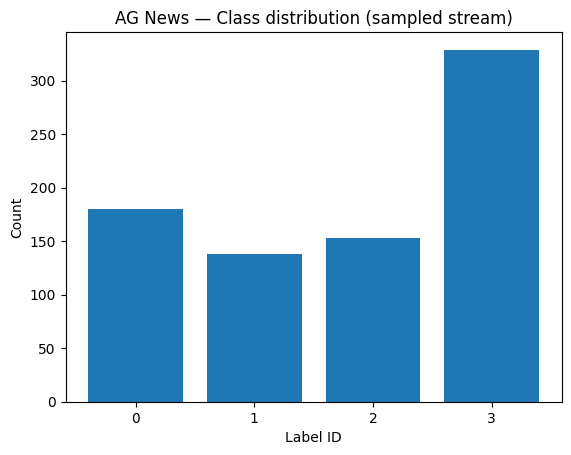

In [8]:
# Bar chart of label frequencies
labels, counts = zip(*sorted(class_counts.items()))
plt.figure()
plt.bar([str(l) for l in labels], counts)
plt.title("AG News — Class distribution (sampled stream)")
plt.xlabel("Label ID")
plt.ylabel("Count")
plt.show()


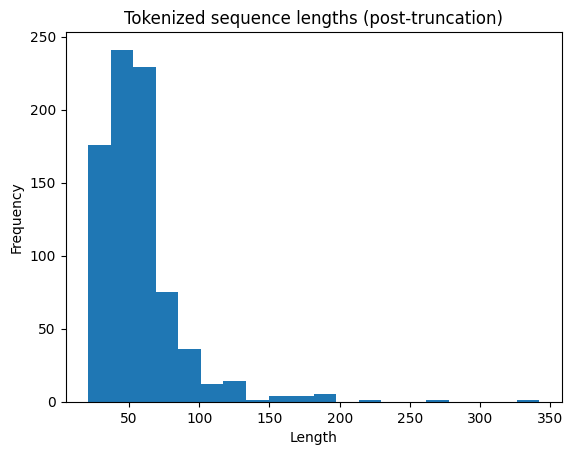

In [9]:
# Histogram of tokenized (post-truncation) sequence lengths
plt.figure()
plt.hist(lengths, bins=20)
plt.title("Tokenized sequence lengths (post-truncation)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


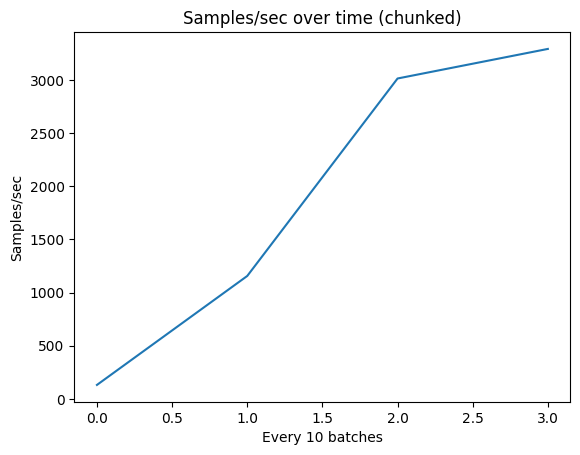

In [10]:
# Quick-and-dirty throughput plot (“samples/sec” over chunks of batches)
CHUNK = 10
speeds = []

# Fresh stream for timing (to avoid exhausting our previous iterator)
stream2 = load_dataset("ag_news", split="train", streaming=True)
stream2 = windowed_shuffle(stream2, buffer_size=SHUFFLE_BUFFER, seed=SEED + 1)
dataset2 = StreamingAGNews(stream2, tok)
loader2 = DataLoader(
    dataset2,
    batch_size=BATCH_SIZE,
    collate_fn=lambda b: dynamic_collate(b, pad_id=tok.pad_token_id, pad_to_multiple_of=PAD_TO_MULTIPLE_OF),
)

n = 0
t0 = time.time()
for i, b in enumerate(loader2):
    n += len(b["labels"])
    if (i + 1) % CHUNK == 0:
        dt = time.time() - t0
        speeds.append((CHUNK * BATCH_SIZE) / dt)
        t0 = time.time()
    if i + 1 >= 40:
        break

plt.figure()
plt.plot(speeds)
plt.title("Samples/sec over time (chunked)")
plt.xlabel(f"Every {CHUNK} batches")
plt.ylabel("Samples/sec")
plt.show()


In [11]:
# Decode a handful of tokenized examples to sanity-check tokenization
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tok.pad_token_id is None:
    tok.pad_token = tok.eos_token if tok.eos_token else tok.cls_token

ds_inspect = load_dataset("ag_news", split="train", streaming=True)
decoded_count = 0
for ex in ds_inspect:
    t = tok(ex["text"], truncation=True, return_tensors="pt")["input_ids"].squeeze(0)
    print(f"[{decoded_count}] {tok.decode(t, skip_special_tokens=True)[:200]}…")
    decoded_count += 1
    if decoded_count >= 3:
        break


[0] wall st. bears claw back into the black ( reuters ) reuters - short - sellers, wall street ' s dwindling \ band of ultra - cynics, are seeing green again.…
[1] carlyle looks toward commercial aerospace ( reuters ) reuters - private investment firm carlyle group, \ which has a reputation for making well - timed and occasionally \ controversial plays in the de…
[2] oil and economy cloud stocks ' outlook ( reuters ) reuters - soaring crude prices plus worries \ about the economy and the outlook for earnings are expected to \ hang over the stock market next week d…
